<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/practice/Student_TimeSeries_Forecasting_Example_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Time Series Analysis 과제**

- 이름 (학번): 예병수 (2526527007)
- 실습 내용:


In [1]:
!pip install pandas-datareader matplotlib seaborn -q

In [2]:
import pandas as pd
import pandas_datareader.data as web
import datetime

# 분석 기간 설정
start = datetime.datetime(2000, 1, 1)
end   = datetime.datetime(2024, 12, 31)

# FRED에서 3개 지표 한 번에 로드
# FEDFUNDS : 미국 기준금리 (%)
# UNRATE   : 실업률 (%)
# CPIAUCSL : 소비자물가지수 (CPI)
df = web.DataReader(
    ['FEDFUNDS', 'UNRATE', 'CPIAUCSL'],
    'fred',
    start, end
)

df.columns = ['금리', '실업률', 'CPI']
print(df.shape)
df.tail()

(300, 3)


,금리,실업률,CPI
DATE,,,
2024-08-01,5.33,4.2,314.062
2024-09-01,5.13,4.1,314.732
2024-10-01,4.83,4.1,315.631
2024-11-01,4.64,4.2,316.528
2024-12-01,4.48,4.1,317.604


In [3]:
# 결측값 확인 및 전방 채우기
print("결측값:\n", df.isnull().sum())
df = df.fillna(method='ffill')

# CPI → 전년 동월 대비 물가상승률(%) 변환
df['물가상승률'] = df['CPI'].pct_change(12) * 100

# 월별 리샘플링 (데이터 빈도 통일)
df = df.resample('MS').mean()

print("\n기초 통계:")
df[['금리', '실업률', '물가상승률']].describe().round(2)

결측값:
 금리     0
실업률    0
CPI    0
dtype: int64

기초 통계:


/tmp/ipykernel_5979/3953911316.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,금리,실업률,물가상승률
count,300.00,300.00,288.00
mean,1.92,5.70,2.55
std,2.02,1.96,1.79
min,0.05,3.40,-1.96
25%,0.14,4.20,1.55
50%,1.21,5.10,2.21
75%,3.53,6.43,3.25
max,6.54,14.80,8.98


/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 52840 (\N{HANGUL SYLLABLE CIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5979/452258285.py:34: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

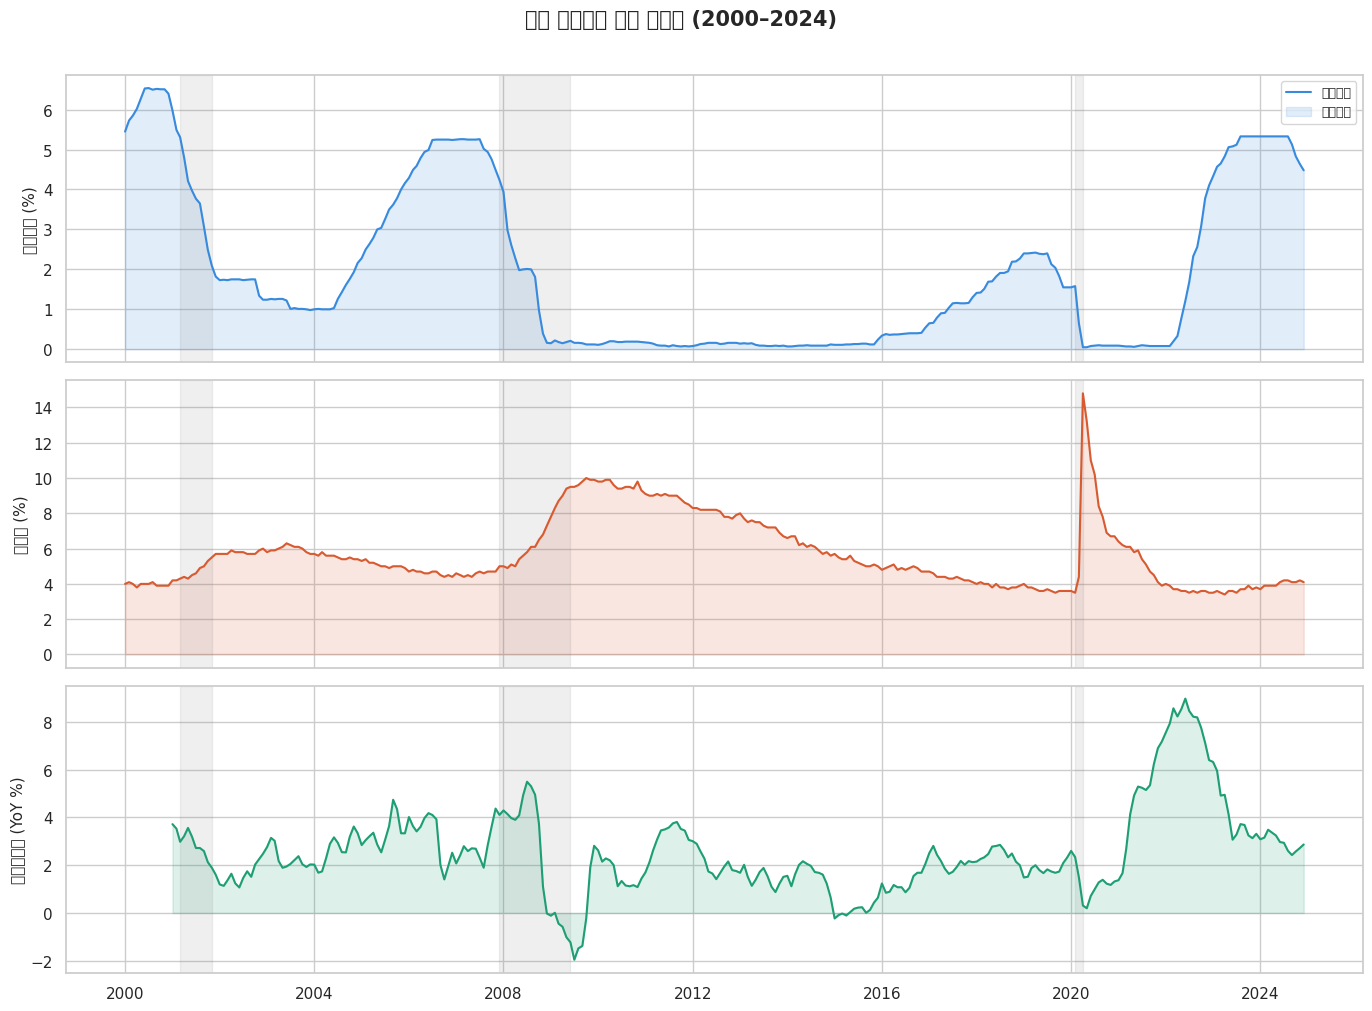

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('미국 거시경제 지표 시계열 (2000–2024)',
             fontsize=15, fontweight='bold', y=1.01)

colors = ['#378ADD', '#D85A30', '#1D9E75']
cols   = ['금리', '실업률', '물가상승률']
labels = ['기준금리 (%)', '실업률 (%)', '물가상승률 (YoY %)']

for ax, col, label, color in zip(axes, cols, labels, colors):
    ax.plot(df.index, df[col], color=color, linewidth=1.5)
    ax.fill_between(df.index, df[col], alpha=0.15, color=color)
    ax.set_ylabel(label, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))

    # 경기침체 구간 음영 (NBER 기준 주요 침체기)
    recessions = [
        ('2001-03', '2001-11'),
        ('2007-12', '2009-06'),
        ('2020-02', '2020-04'),
    ]
    for s, e in recessions:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=0.12, color='gray', label='_nolegend_')

axes[0].legend(['기준금리', '경기침체'],
               loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fred_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

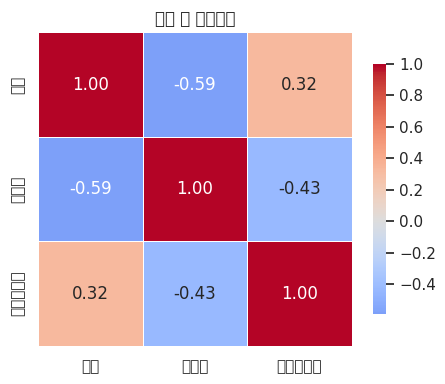

In [5]:
# 변수 간 상관관계 시각화
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[['금리', '실업률', '물가상승률']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('지표 간 상관계수', fontsize=12)
plt.tight_layout()
plt.show()